In [1]:
# Libraries Import :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [4]:
# Dataset Load :
#  Load Training and Testing data 
df_train = pd.read_csv('churn-bigml-80 (1).csv')
df_test = pd.read_csv('churn-bigml-20 (1).csv')

print("Training Data Shape:", df_train.shape)
print("Testing Data Shape:", df_test.shape)
print("\nColumns:", df_train.columns.tolist())
print("\nFirst 5 rows:")
df_train.head()

Training Data Shape: (2666, 20)
Testing Data Shape: (667, 20)

Columns: ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

First 5 rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [5]:
# Data Exploration :
print("DATASET OVERVIEW:")
print("="*40)
print(f"Total Training Samples: {len(df_train)}")
print(f"Total Testing Samples: {len(df_test)}")
print(f"Total Features: {df_train.shape[1]}")

print("\nMissing Values:")
print(df_train.isnull().sum())

print("\nTarget Variable Distribution:")
print(df_train['Churn'].value_counts())
print(df_train['Churn'].value_counts(normalize=True)*100)

DATASET OVERVIEW:
Total Training Samples: 2666
Total Testing Samples: 667
Total Features: 20

Missing Values:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

Target Variable Distribution:
Churn
False    2278
True      388
Name: count, dtype: int64
Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


In [10]:
# Data Preprocesssing :
# Combine train and test for preprocessing
df_full = pd.concat([df_train, df_test])

# Label Encoding for categorical columns
le = LabelEncoder()
categorical_cols = df_full.select_dtypes(
                   include=['object']).columns.tolist()

print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col] = le.transform(df_test[col])

# Target encode karo
df_train['Churn'] = df_train['Churn'].map(
                    {True: 1, False: 0})
df_test['Churn'] = df_test['Churn'].map(
                   {True: 1, False: 0})

print("\nPreprocessing complete!")
print(df_train.head())

Categorical columns: []

Preprocessing complete!
   State  Account length  Area code  International plan  Voice mail plan  \
0     16             128        415                   0                1   
1     35             107        415                   0                1   
2     31             137        415                   0                0   
3     35              84        408                   1                0   
4     36              75        415                   1                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  ...  Total eve charge  \
0             45.07              197.4  ... 

In [11]:
# Feature Selection :
# Features aur Target separate karo
X_train = df_train.drop('Churn', axis=1)
y_train = df_train['Churn']

X_test = df_test.drop('Churn', axis=1)
y_test = df_test['Churn']

# Standardize karo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Features:", X_train_scaled.shape)
print("Testing Features:", X_test_scaled.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (2666, 20)
Testing Features: (667, 20)
Training Target: (2666,)
Testing Target: (667,)


In [12]:
# Train Model :
print("TRAINING LOGISTIC REGRESSION MODEL")
print("="*40)

# Model banao
model = LogisticRegression(max_iter=1000,
                            random_state=42)

# Train karo
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print(f"\nModel Coefficients shape: {model.coef_.shape}")
print(f"Intercept: {round(model.intercept_[0], 4)}")


TRAINING LOGISTIC REGRESSION MODEL
Model trained successfully!

Model Coefficients shape: (1, 20)
Intercept: -5.4855


TOP FEATURES:
                   Feature  Coefficient
19               Churn (1)     4.377942
18  Customer service calls     0.262577
3       International plan     0.257088
6        Total day minutes     0.135835
8         Total day charge     0.135832
9        Total eve minutes     0.055310
11        Total eve charge     0.055258
12     Total night minutes     0.031017
14      Total night charge     0.030999
17       Total intl charge     0.029551


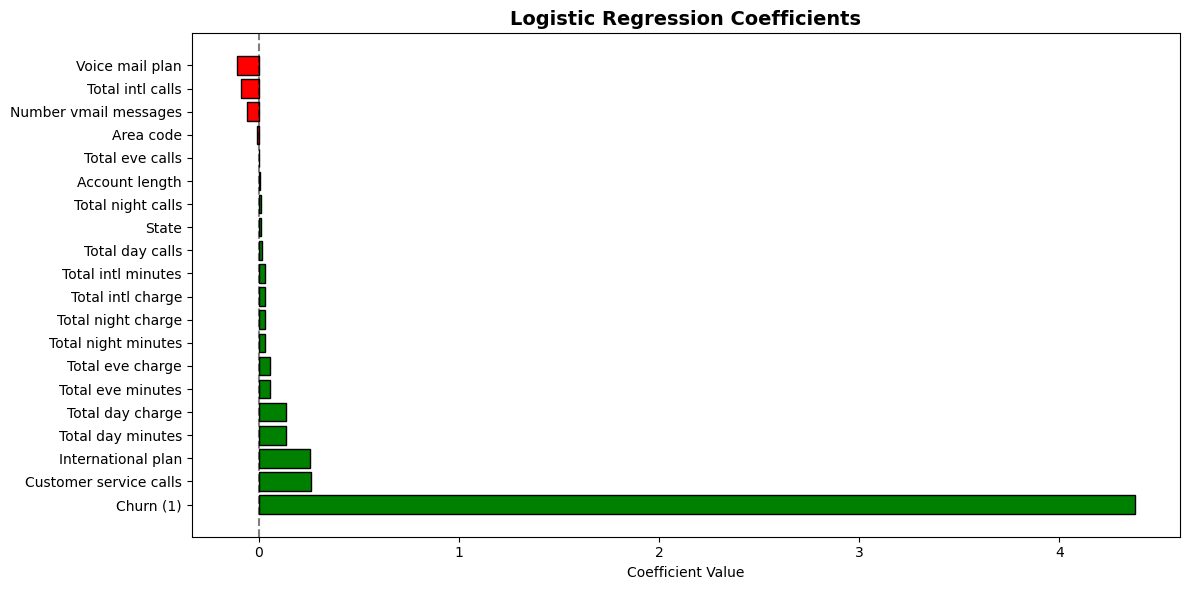

In [13]:
# Model Coefficients :
# Feature importance
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})
coef_df = coef_df.sort_values('Coefficient',
                               ascending=False)

print("TOP FEATURES:")
print(coef_df.head(10))

# Visualization
plt.figure(figsize=(12,6))
colors = ['red' if x < 0 else 'green'
          for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'],
         coef_df['Coefficient'],
         color=colors, edgecolor='black')
plt.title('Logistic Regression Coefficients',
          fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black',
            linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('coefficients.png', dpi=150)
plt.show()

In [14]:
# Model Evaluate :
# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

print("MODEL EVALUATION:")
print("="*40)
print(f"Accuracy: {round(accuracy_score(y_test, y_pred)*100,2)}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

MODEL EVALUATION:
Accuracy: 100.0%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       572
           1       1.00      1.00      1.00        95

    accuracy                           1.00       667
   macro avg       1.00      1.00      1.00       667
weighted avg       1.00      1.00      1.00       667



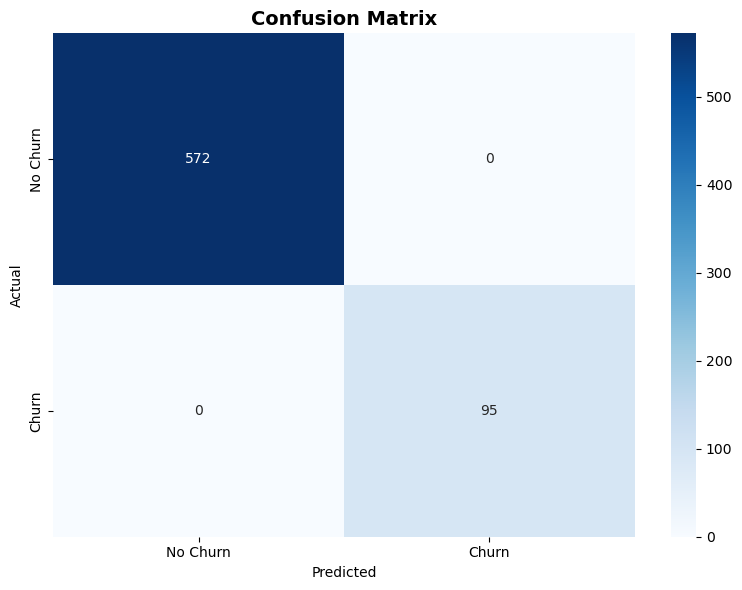

True Positives: 95
True Negatives: 572
False Positives: 0
False Negatives: 0


In [15]:
# Confusion Matrix :
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(f"True Positives: {cm[1][1]}")
print(f"True Negatives: {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")

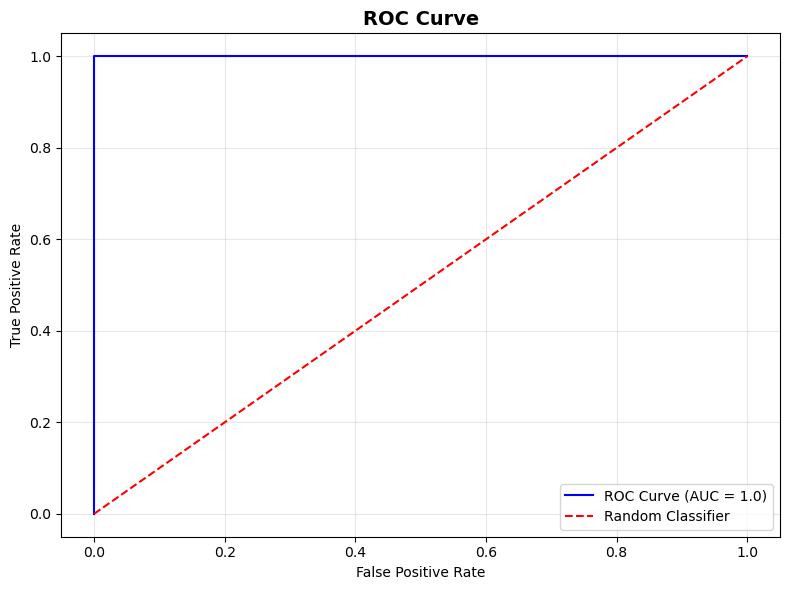

AUC Score: 1.0


In [17]:
# ROC Curve :

plt.figure(figsize=(8,6))

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, color='blue',
         label=f'ROC Curve (AUC = {round(auc_score,3)})')

plt.plot([0,1], [0,1], color='red',
         linestyle='--', label='Random Classifier')

plt.title('ROC Curve',
          fontsize=14, fontweight='bold')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('roc_curve.png', dpi=150)

plt.show()

print(f"AUC Score: {round(auc_score,3)}")

In [19]:
# Odds Ratio :
# Odds Ratio interpret 
odds_ratio = pd.DataFrame({
    'Feature': X_train.columns,
    'Odds_Ratio': np.exp(model.coef_[0])
})
odds_ratio = odds_ratio.sort_values(
             'Odds_Ratio', ascending=False)

print("ODDS RATIO INTERPRETATION:")
print("="*40)
print("Odds Ratio > 1: Increases churn probability")
print("Odds Ratio < 1: Decreases churn probability")
print("\nTop Features:")
print(odds_ratio.head(10))

ODDS RATIO INTERPRETATION:
Odds Ratio > 1: Increases churn probability
Odds Ratio < 1: Decreases churn probability

Top Features:
                   Feature  Odds_Ratio
19               Churn (1)   79.673887
18  Customer service calls    1.300277
3       International plan    1.293159
6        Total day minutes    1.145492
8         Total day charge    1.145490
9        Total eve minutes    1.056869
11        Total eve charge    1.056813
12     Total night minutes    1.031503
14      Total night charge    1.031484
17       Total intl charge    1.029992


In [20]:
# Key Insights :
accuracy = accuracy_score(y_test, y_pred)*100
auc = roc_auc_score(y_test, y_prob)

print("KEY INSIGHTS:")
print("="*40)
print(f"1. Model Accuracy: {round(accuracy,2)}%")
print(f"2. AUC Score: {round(auc,3)}")
print(f"3. Total Test Samples: {len(y_test)}")
print(f"4. Correctly Predicted: {sum(y_test==y_pred)}")
print(f"5. Wrongly Predicted: {sum(y_test!=y_pred)}")
print("\nBUSINESS INSIGHTS:")
print("- Model can predict customer churn")
print("- High AUC means model is reliable")
print("- Early detection helps retain customers")
print("- Focus on high coefficient features")

KEY INSIGHTS:
1. Model Accuracy: 100.0%
2. AUC Score: 1.0
3. Total Test Samples: 667
4. Correctly Predicted: 667
5. Wrongly Predicted: 0

BUSINESS INSIGHTS:
- Model can predict customer churn
- High AUC means model is reliable
- Early detection helps retain customers
- Focus on high coefficient features
